# 02-02 - One Number per Block

In 02-01 we read what the town's files say about themselves and found the row behind our own classroom. The lecture said that a spatial join is a join whose key is geometry, that a dissolve is the spatial group by, and that the practice belongs to us.

Here is the practice. We take the places to eat and turn them into one number per zoning category, then eight thousand parcels with their assessed values into one number per tax block. On the way we meet the join that quietly counts things twice, the check that catches it, and the third number for "how many blocks are there" that turns out to be as true as the other two.

Save your own copy first, with `-mywork` in the name.

In [1]:
import json

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

## Four files, one working system

The parcels with the tax roll come from the State, the zoning districts and the tax blocks from the municipality, and the places to eat from OpenStreetMap by way of P01. Four files, and as 02-01 taught us, the first question for each is what it arrived in:

In [2]:
tax_roll = gpd.read_file("data/njgin_parcels.gpkg", layer="parcels")
zoning = gpd.read_file("data/princeton_municipal.gpkg", layer="zoning")
blocks = gpd.read_file("data/princeton_municipal.gpkg", layer="tax_blocks")
food = gpd.read_file("data/princeton_food.geojson")

for name, layer in [("tax roll", tax_roll), ("zoning", zoning), ("blocks", blocks), ("food", food)]:
    print(f"{name:10} {layer.crs}   {len(layer):,} rows")

tax roll   EPSG:3857   8,391 rows
zoning     EPSG:6527   126 rows
blocks     EPSG:3424   484 rows
food       EPSG:4326   92 rows


Four coordinate reference systems in four files, i.e. Web Mercator, feet on two datum realisations, and degrees. Every join in this notebook needs its two sides in the same system, and every distance and area needs metres, so we do the conversion once, here, and never think about it again. The system is the one every P01 measurement used, and the one the lecture's numbers were computed in:

In [3]:
metric = "EPSG:26918"

tax_roll = tax_roll.to_crs(metric)
zoning = zoning.to_crs(metric)
blocks = blocks.to_crs(metric)
food = food.to_crs(metric)

Note that nothing printed. A conversion that succeeds is silent, and from here on every layer in memory is in metres, whatever the file on disk says. The file on disk is unchanged.

The places to eat are an OpenStreetMap extract, mapped by volunteers and licensed ODbL, which is why they carry an attribution and why we say so whenever we use them.

## A point cannot straddle

Let us start with the join that is safe, and see why it is. Which zoning district is each place to eat in? The key is geometry, and the predicate is `within`:

In [4]:
food_in_zone = gpd.sjoin(food, zoning[["Zone", "ZONING_CAT", "geometry"]], predicate="within")
len(food_in_zone)

91

Ninety one rows, for ninety two places. A point lies inside exactly one polygon or inside none, so a join of points into polygons can lose a row and can never double one. Note that this holds only while the polygons themselves do not overlap, which cadastral polygons are not supposed to do and, as the tax blocks below show, these do. The one place that is missing sits on land the zoning layer does not cover, i.e. a road, since this layer has the roads clipped out, and a point on a road belongs to no district.

Now the table we actually wanted, the places to eat by zoning category:

In [5]:
food_in_zone["ZONING_CAT"].value_counts()

ZONING_CAT
BUSINESS-MIXED USE    86
RESIDENTIAL            3
EDUCATIONAL            2
Name: count, dtype: int64

Read the table. Most places to eat sit where the zoning says businesses go, which is reassuring and not very interesting. Any place that lands in a residential category is interesting, and it is a question for the zoning office rather than an error in the data. A restaurant in a residential zone is either older than the zoning, or a use the code permits, or a mistake on one of the two maps, and the join cannot tell you which. It can only tell you where to look.

## The join that counts things twice

Now the join that is not safe. Which tax block is each parcel in? A parcel is a polygon, and the predicate that comes to mind is `intersects`:

In [6]:
touching = gpd.sjoin(tax_roll, blocks[["BLOCK_NO", "geometry"]], predicate="intersects")

print(f"rows after the join   {len(touching):,}")
print(f"parcels before it     {len(tax_roll):,}")
print(f"assessed value after  {touching['NET_VALUE'].sum() / 1e9:.2f} billion dollars")
print(f"assessed value before {tax_roll['NET_VALUE'].sum() / 1e9:.2f} billion dollars")

rows after the join   9,428
parcels before it     8,391
assessed value after  11.34 billion dollars
assessed value before 9.50 billion dollars


More rows than there are parcels, and nearly two billion dollars more than the town is assessed at. Every parcel that touches more than one block was copied once for each block it touches, and its value was counted once for each copy. A parcel that straddles three blocks is in there three times. Nothing raised an error, and a total that is far too large looks exactly like a total that is right.

## The fix, and the check

A polygon can straddle a line. Its **centroid** cannot. The centroid is a shape's centre point, the average position of all its area, and if we replace each parcel by that point and ask `within`, no parcel can be copied into two blocks by straddling. Let us do that, and this time count two things, the rows that came back and the distinct parcels among them:

In [7]:
centres = tax_roll.copy()
centres["geometry"] = centres.geometry.centroid

assigned = gpd.sjoin(centres, blocks[["BLOCK_NO", "geometry"]], predicate="within")

print(f"rows after the join   {len(assigned):,}")
print(f"distinct parcels      {assigned['PAMS_PIN'].nunique():,}")
print(f"parcels before it     {len(tax_roll):,}")

rows after the join   8,390
distinct parcels      8,385
parcels before it     8,391


Eight thousand three hundred and ninety rows, one short of the parcel count. Had we stopped at the first line we would have concluded that one parcel was lost and everything else was fine. The second line says otherwise. Only 8,385 distinct parcels are in the result. Five parcels appear twice and six appear not at all, and the row count hid both behind a number that looked one short. **Count keys, not rows.** The key here is `PAMS_PIN`, the State's identifier for one parcel, which 02-01 met. A count of rows tells you how big a table is; only a count of distinct identifiers tells you how many things are in it.

Let us see the five that appear twice. `duplicated(keep=False)` marks every row whose identifier appears more than once, both copies and not just the second:

In [8]:
twice = assigned["PAMS_PIN"].duplicated(keep=False)

print(f"{assigned[twice]['PAMS_PIN'].nunique()} parcels doubled")
assigned[twice][["PAMS_PIN", "PROP_LOC", "BLOCK_NO"]].sort_values("PAMS_PIN")

5 parcels doubled


,PAMS_PIN,PROP_LOC,BLOCK_NO
2106,1114_11003_64,168 FITZRANDOLPH RD,11003
2106,1114_11003_64,168 FITZRANDOLPH RD,50.01
4476,1114_11003_65,150 FITZRANDOLPH RD,11003
4476,1114_11003_65,150 FITZRANDOLPH RD,50.01
2113,1114_11003_66,171 WESTERN WAY,11003
2113,1114_11003_66,171 WESTERN WAY,50.01
2112,1114_11003_67,139 BROADMEAD,11003
2112,1114_11003_67,139 BROADMEAD,50.01
4477,1114_11003_68,157 BROADMEAD,11003
4477,1114_11003_68,157 BROADMEAD,50.01


Five parcels, each listed under two different block numbers. That can only happen if two block polygons overlap, and they do. One block in this layer is drawn inside another. A point inside the smaller is inside both. Overlapping blocks are not supposed to exist in a cadastral map, and now you know that in this one they do, which is the kind of thing a reader of your map will never know unless you tell them.

We want one number per parcel, so we keep one row for each, and the line that rebuilds this table in 02-04 carries a comment saying so:

In [9]:
assigned = assigned.drop_duplicates("PAMS_PIN")
len(assigned)

8385

Eight thousand three hundred and eighty five rows, one per parcel. Note that `drop_duplicates` keeps whichever copy the join returned first, i.e. nothing here chose between the two block numbers on purpose.

Now the six that appear not at all, i.e. the parcels whose centroid fell outside every block. The `~` means not, so the line keeps every parcel whose identifier is not among the assigned ones:

In [10]:
lost = tax_roll[~tax_roll["PAMS_PIN"].isin(assigned["PAMS_PIN"])]

print(f"{len(lost)} parcels lost")
lost[["PAMS_PIN", "PROP_LOC", "PROP_CLASS", "CALC_ACRE", "NET_VALUE"]]

6 parcels lost


,PAMS_PIN,PROP_LOC,PROP_CLASS,CALC_ACRE,NET_VALUE
43,1114_11602_2,DELAWARE & RARITAN CANAL,15C,2.000,178000
181,1114_4201_21,50 REDDING CIRCLE,15C,9.780,11500000
258,1114_9702_1,ARBORS OPEN SPACE,15F,2.400,0
3319,1114_1303_8,CORDOVA ROAD,1,0.000,0
8249,1114_45.01_101_D89,FACULTY ROAD,15B,1.780,648500
8278,1114_20.01_84.01,PALMER SQ EAST AIR RIGHTS,4A,0.069,30000


Look at what they are. A canal, a piece of open space, a vacant strip on Cordova Road whose recorded acreage is zero although its polygon is not, a private stretch of Faculty Road, the air rights above Palmer Square, and one public property assessed at eleven and a half million dollars. The property classes say which is which, i.e. anything beginning with 15 is exempt, 1 is vacant land and 4A is commercial. The pattern is not random. Three of them have centres that lie outside their own outline, because long thin shapes and hollow shapes do that, and the other three sit on land the block map leaves as street or does not bother to cover, since nobody pays tax on it. A centroid is a good stand-in for a parcel until it is not, and these six are where it is not.

Now the check. If the assessed value of the town is conserved by the join, then the value before minus the value after must be exactly the value of the parcels we lost:

In [11]:
before = tax_roll["NET_VALUE"].sum()
after = assigned["NET_VALUE"].sum()

print(f"before          {before:>16,.0f} dollars")
print(f"after           {after:>16,.0f} dollars")
print(f"difference      {before - after:>16,.0f} dollars")
print(f"the six we lost {lost['NET_VALUE'].sum():>16,.0f} dollars")

before             9,501,720,100 dollars
after              9,489,363,600 dollars
difference            12,356,500 dollars
the six we lost       12,356,500 dollars


To the dollar. The books balance, and every row that left the table can be named. That is the check, and it generalises. Whenever you aggregate something that should be conserved, money, people, buildings, the difference between before and after must be a list of rows you can point at. If it is not, something you have not found is doubling or dropping rows, and the number you are about to report is wrong by an amount you cannot see.

The pipeline that made this data ran the same accounting, so let us compare:

In [12]:
reference = json.load(open("data/ground_truth.json"))["p02"]
reference["join"]

{'intersects_rows': 9428,
 'intersects_sum_usd': 11338833100,
 'centroid_rows': 8390,
 'centroid_distinct': 8385,
 'centroid_doubled': 5,
 'centroid_sum_usd': 9489363600,
 'unassigned': 6,
 'unassigned_value_usd': 12356500,
 'food_in_zoning_rows': 91,
 'key_matched': 8338,
 'key_match_share': 0.994}

Note that the reference records the rows, the distinct parcels, the doubled ones and the lost ones, with the value of what was lost. A pipeline that only recorded the answer it liked would be worthless as a check. Ignore the two entries beginning `key_`; they belong to 02-05, which joins the State's file to the municipality's on a key built from the block, the lot and the qualifier.

## One number per block

Now the aggregation. The assessed value of a block is the sum over the parcels whose centroids fall in it, which is an ordinary `groupby` on the joined table. `groupby` collects the rows that share a value in one column, here the block number, and applies one operation to each group, here `sum`:

In [13]:
value_per_block = assigned.groupby("BLOCK_NO")["NET_VALUE"].sum()

print(f"block polygons         {len(blocks)}")
print(f"distinct block numbers {blocks['BLOCK_NO'].nunique()}")
print(f"blocks with a value    {len(value_per_block)}")

block polygons         484
distinct block numbers 455
blocks with a value    450


Three answers to "how many blocks are there", and all three are right about something. There are 484 polygons in the layer. There are 455 distinct block numbers, because a block that a road cuts in two is drawn as two polygons with one number. And the number of blocks with a value is how many received at least one parcel centroid. Note that a block can receive none in two ways, i.e. the land really holds no parcel, or a parcel covers the block but has its centre in the block next door, which is the same trap as the six above.

The lecture called dissolve the spatial group by, and that is exactly what it is. The polygons are grouped by a column and their shapes are merged, so a block split by a road becomes one block again. Let us dissolve the blocks by their number and attach the values. Note that the `.join` on the second line is an ordinary table join on the block number, which both tables now carry as their index, and not a spatial one. The spatial work was done by `sjoin` above; this line only puts each number next to its shape:

In [14]:
block_shapes = blocks.dissolve(by="BLOCK_NO")[["geometry"]]
block_value = block_shapes.join(value_per_block)

print(f"{int(block_value['NET_VALUE'].isna().sum())} blocks received no parcel and have no value")
block_value.head()

5 blocks received no parcel and have no value


,geometry,NET_VALUE
BLOCK_NO,,
1.01,"POLYGON ((527214.28 4466665.33, 527124.739 446...",27855500.0
10.01,"POLYGON ((527888.836 4466065.789, 527998.926 4...",9304900.0
10.02,"POLYGON ((528049.553 4466138.019, 527961.962 4...",101731400.0
10001,"POLYGON ((527725.465 4465321.902, 527720.69 44...",38562100.0
1001,"POLYGON ((529699.007 4470593.039, 529562.742 4...",6456600.0


One row per block number, with its merged shape and its total assessed value, and a missing value, shown as `NaN`, for the handful of blocks where no parcel landed. That table is the raw material for the poster map in 02-04, which rebuilds it in a single cell. Note that 02-03 steps away from the blocks and works on the lecture's own grid first.

## Exempt is not worthless

Before we draw anything, one column deserves a look, because it decides what the maps in 02-04 are allowed to say. The tax roll's `PROP_CLASS` is the assessor's classification, and every class beginning with 15 is exempt from property tax: public property, schools, churches, cemeteries. Princeton University is class 15B, other school property. Let us see how much of the town that is:

In [15]:
exempt = tax_roll["PROP_CLASS"].str.startswith("15")

print(f"exempt parcels           {int(exempt.sum())} of {len(tax_roll):,}")
print(f"share of assessed value  {tax_roll.loc[exempt, 'NET_VALUE'].sum() / tax_roll['NET_VALUE'].sum():.1%}")
print(f"share of the land        {tax_roll.loc[exempt, 'CALC_ACRE'].sum() / tax_roll['CALC_ACRE'].sum():.1%}")

exempt parcels           757 of 8,391
share of assessed value  26.6%
share of the land        24.6%


About a quarter of Princeton's assessed value, on about a quarter of its land, pays no property tax. Note that exempt land is still assessed, which is why the E-Wing had a value in 02-01. The number exists; it is simply not taxed.

This matters because a map of tax paid per block would colour the campus as zero, and zero on that map would not mean "worthless" but "exempt", which is a different fact wearing the same colour. Deciding what the map is a map of, and which rows belong in it, is the universe question the lecture raised, and 02-04 answers it out loud.

## The map we are not ready to read

Here is the block table drawn the fastest way possible, one line, every decision left unmade:

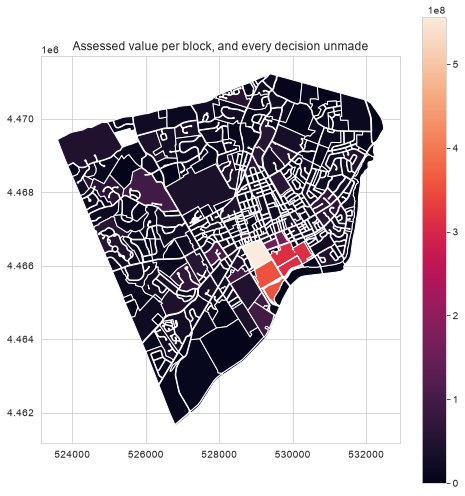

In [16]:
ax = block_value.plot(column="NET_VALUE", legend=True, figsize=(7, 7))
ax.set_title("Assessed value per block, and every decision unmade")
fig = ax.figure
fig.tight_layout()

It is a map of a total, on a continuous colour ramp, with a legend whose numbers are not dollars but multiples of the factor printed at the top of the bar, an axis in metres, and nothing to say which blocks are exempt, which are large, or whether the pattern means anything. It looks finished. It is not. Every choice the lecture listed, the classification, the colours, the denominator, the universe, has been made for us by defaults, and 02-03 is where we start making them ourselves.

## Your turn

The municipality publishes several hundred resident reports of dead deer, a layer that behaves like a 311 service request feed. Two questions, and they have different answers. Which zoning category has the most reports? And which has the most reports per square kilometre? The pieces you need all appear above, i.e. `sjoin` with `within` to put each report in its district, `groupby` with `size`, which counts the rows in each group, and `dissolve` by category with `.geometry.area` for the denominator. Two things you have not seen: `idxmax` names the row that holds the largest value, and dividing one table by another divides them row by row where their labels match. Some reports will land in no district at all, and it is worth counting how many and saying where they must be.

The cell below has the lines written out with three blanks. Fill them, remove the `#` at the start of each line, and run it. Write both categories on your handout, and if they differ, say in one sentence why. There is no class answer on the board. The point is the difference between the two numbers and your account of it.

In [17]:
deer = gpd.read_file("data/princeton_municipal.gpkg", layer="deer_reports").to_crs(metric)

# Your attempt. Fill the three blanks, then delete the # at the start of each line and run.
#
# in_zone = gpd.sjoin(deer, zoning[["ZONING_CAT", "geometry"]], predicate="___")
# by_count = in_zone.groupby("___").size()
# area_km2 = zoning.dissolve(by="___").geometry.area / 1e6
# by_rate = by_count / area_km2
# print("most reports          ", by_count.idxmax())
# print("most reports per km2  ", by_rate.idxmax())
#
# Then count the reports that landed in no district, with len(deer) - len(in_zone).

## Check your understanding

1. Joining parcels to blocks with `intersects` gave more rows than parcels and a larger total than the town. Where did the extra rows come from, and why did centroids remove them?
2. Food places joined to zones gave 91 rows for 92 places, with no double counting. What property of a point made that safe, and where is the missing place?
3. `sum` was the right aggregation for assessed value. Would it be right for year built? What would you use instead, and what would still be misleading about the result?
4. The block layer gave 484, 455 and 450 as answers to "how many blocks". Say what each one counts, and which you would report to someone planning a survey of every block.

## Where we are

You can join points into polygons and polygons into polygons, you know which of those can double a row and which can lose one, and you have a check that tells you when either has happened. You can turn eight thousand parcels into one number per block with a `groupby`, and merge split blocks back together with a `dissolve`. And you know that a quarter of this town's assessed value is exempt, which is a fact the maps must not hide.

The habit worth keeping: after any join or aggregation, compare a sum before to the sum after, and account for the difference in rows.

In 02-03 we take the lecture's own grid and classify one variable three ways, and watch three correct maps say three different things.

## Further resources

Nothing in this course requires anything below.

The geopandas guide to spatial joins lists every predicate and shows the `index_right` column that a join quietly adds: https://geopandas.org/en/stable/docs/user_guide/mergingdata.html. The same guide's page on dissolve is the spatial group by with pictures: https://geopandas.org/en/stable/docs/user_guide/aggregation_with_dissolve.html

The property class codes of the MOD-IV tax list are defined by the New Jersey Division of Taxation in its handbook for assessors, where class 15A to 15F are the exempt classes: https://www.nj.gov/treasury/taxation/pdf/assessorshandbook.pdf

The places to eat are an OpenStreetMap extract, snapshot as recorded in `data/README.org`, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright. The parcels with the tax roll are published by NJGIN Open Data, which asks to be acknowledged, and the zoning, block and deer layers by the Municipality of Princeton.

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The deer reports by category, twice:

```python
import geopandas as gpd

metric = "EPSG:26918"
zoning = gpd.read_file("data/princeton_municipal.gpkg", layer="zoning").to_crs(metric)
deer = gpd.read_file("data/princeton_municipal.gpkg", layer="deer_reports").to_crs(metric)

in_zone = gpd.sjoin(deer, zoning[["ZONING_CAT", "geometry"]], predicate="within")
by_count = in_zone.groupby("ZONING_CAT").size()
area_km2 = zoning.dissolve(by="ZONING_CAT").geometry.area / 1e6
by_rate = (by_count / area_km2).dropna()
print("most reports          ", by_count.idxmax())
print("most reports per km2  ", by_rate.idxmax())
print(len(deer) - len(in_zone), "reports landed in no district")
```

Note that `len(deer) - len(in_zone)` is a large number. Nearly all of the reports that fall out are the ones the municipality records as on the roadway, and this zoning layer has the roads clipped out, so about a third of the layer belongs to no district. That is not a flaw in your join. It is a fact about the two layers that you now know and a reader of your map would not.